<a href="https://colab.research.google.com/github/PutriBalqisAfradinata/PutriBalqisAfradinata_2411531009_ML2526/blob/main/Praktikum5/TugasCrossValidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **===== TUGAS CROSS VALIDATION =====**

1. 1. Import library

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

2. Load dataset

In [3]:
url_train = "https://raw.githubusercontent.com/PutriBalqisAfradinata/PutriBalqisAfradinata_2411531009_ML2526/refs/heads/main/Praktikum5/train.csv"
df = pd.read_csv(url_train)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3. Preprocessing

In [4]:
# Drop kolom tidak penting
df = df.drop(columns=["Cabin", "Name", "Ticket"], errors='ignore')

# Missing value
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"] = df["Fare"].fillna(df["Fare"].mean())

# Encoding
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

4. Pisahkan fitur & target

In [5]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

5. Buat model Random Forest

In [6]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

6. K-Fold = 5

In [7]:
kf_5 = KFold(n_splits=5, shuffle=True, random_state=42)

acc_5 = cross_val_score(model, X, y, cv=kf_5, scoring='accuracy')
prec_5 = cross_val_score(model, X, y, cv=kf_5, scoring='precision')
rec_5 = cross_val_score(model, X, y, cv=kf_5, scoring='recall')
f1_5 = cross_val_score(model, X, y, cv=kf_5, scoring='f1')

print("=== Random Forest (K=5) ===")
print("Accuracy:", acc_5.mean())
print("Precision:", prec_5.mean())
print("Recall:", rec_5.mean())
print("F1 Score:", f1_5.mean())

=== Random Forest (K=5) ===
Accuracy: 0.8238152030632101
Precision: 0.8155848404575459
Recall: 0.7007123413093561
F1 Score: 0.7525774706421949


7. K-Fold = 10

In [10]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

acc = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
prec = cross_val_score(model, X, y, cv=kf, scoring='precision')
rec = cross_val_score(model, X, y, cv=kf, scoring='recall')
f1 = cross_val_score(model, X, y, cv=kf, scoring='f1')

print("=== Random Forest (K=10) ===")
print("Accuracy:", acc.mean())
print("Precision:", prec.mean())
print("Recall:", rec.mean())
print("F1 Score:", f1.mean())

=== Random Forest (K=10) ===
Accuracy: 0.8316229712858927
Precision: 0.8199579192124832
Recall: 0.7182886906044801
F1 Score: 0.7640828077565825


8. Train Model Final

In [11]:
model.fit(X, y)

RandomForestClassifier(random_state=42)

9. Visualisasi Feature Importance

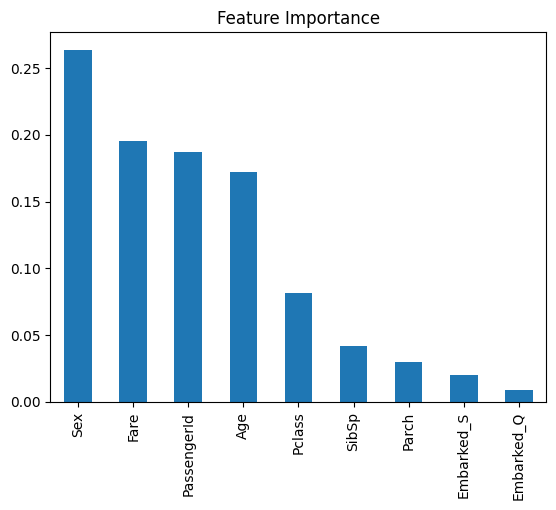

In [12]:
importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure()
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

10. Confusion Matrix

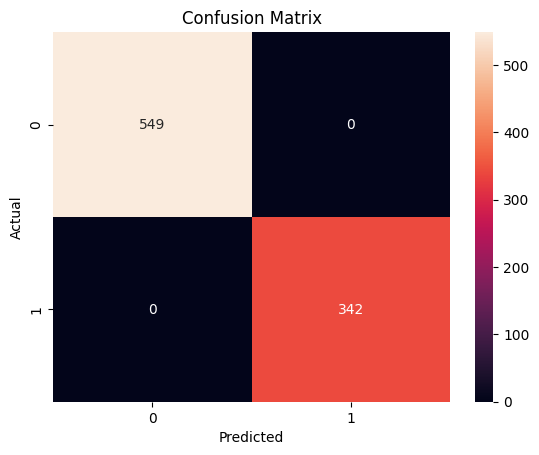

In [13]:
y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

== test ==

11. Load Data Test

In [15]:
url_test = "https://raw.githubusercontent.com/PutriBalqisAfradinata/PutriBalqisAfradinata_2411531009_ML2526/refs/heads/main/Praktikum5/test.csv"
test = pd.read_csv(url_test)

12. Simpan PassengerId

In [16]:
passenger_id = test["PassengerId"]

13. Preprocessing TEST

In [17]:
test = test.drop(columns=["Cabin", "Name", "Ticket"], errors='ignore')

test["Age"] = test["Age"].fillna(test["Age"].mean())
test["Fare"] = test["Fare"].fillna(test["Fare"].mean())
test["Embarked"] = test["Embarked"].fillna(test["Embarked"].mode()[0])

test["Sex"] = test["Sex"].map({"male": 0, "female": 1})
test = pd.get_dummies(test, columns=["Embarked"], drop_first=True)

# Samakan kolom dengan train
test = test.reindex(columns=X.columns, fill_value=0)

14. Prediksi

In [18]:
predictions = model.predict(test)

15. Buat Submission

In [19]:
submission = pd.DataFrame({
    "PassengerId": passenger_id,
    "Survived": predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


16. Simpan File

In [20]:
submission.to_csv("submission_rf.csv", index=False)

17. Bandingkan dengan Gender Baseline

In [21]:
gender = pd.read_csv("https://raw.githubusercontent.com/PutriBalqisAfradinata/PutriBalqisAfradinata_2411531009_ML2526/refs/heads/main/Praktikum5/gender_submission.csv")

comparison = pd.DataFrame({
    "PassengerId": submission["PassengerId"],
    "Model": submission["Survived"],
    "Gender_Baseline": gender["Survived"]
})

comparison.head()

,PassengerId,Model,Gender_Baseline
0,892,0,0
1,893,0,1
2,894,0,0
3,895,0,0
4,896,0,1


In [22]:
(comparison["Model"] == comparison["Gender_Baseline"]).mean()

np.float64(0.7966507177033493)